#Εξόρυξη Δεδομένων Άσκηση 3 Ερώτηση 4

ΟΜΑΔΑ: Αριστείδης Νικολακόπουλος (cs5308), Χρήστος Γιαμαλής (ma12834)

USING 2 FREE PASSES

Question4 Code:

Movie-User Matrix Shape: (2245, 671)

Question 4: UCF with PPR
Calculating User Cosine Similarity (Train Set)...

Building Graph (m=3)...
Running Personalized PageRank for all users...
Result: m=3, k=5, RMSE=1.0269
Result: m=3, k=10, RMSE=0.9996
Result: m=3, k=20, RMSE=0.9755
Result: m=3, k=50, RMSE=0.9664

Building Graph (m=5)...
Running Personalized PageRank for all users...
Result: m=5, k=5, RMSE=1.0270
Result: m=5, k=10, RMSE=0.9907
Result: m=5, k=20, RMSE=0.9595
Result: m=5, k=50, RMSE=0.9426

Building Graph (m=10)...
Running Personalized PageRank for all users...
Result: m=10, k=5, RMSE=1.0171
Result: m=10, k=10, RMSE=0.9801
Result: m=10, k=20, RMSE=0.9495
Result: m=10, k=50, RMSE=0.9237


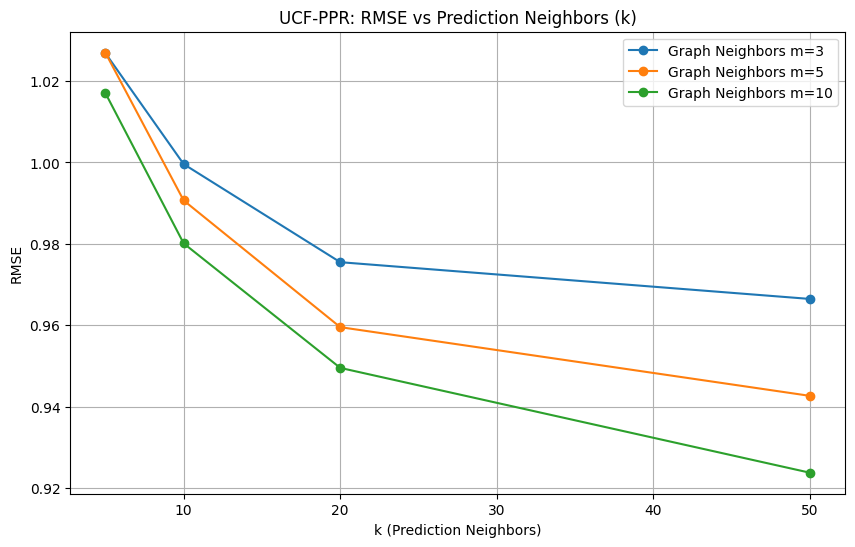

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
from ast import literal_eval
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, precision_score, recall_score, accuracy_score, make_scorer, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, train_test_split, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import pairwise_distances
import gensim.downloader as api
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec
warnings.filterwarnings("ignore")

RATINGS_PATH = 'ratings_small.csv'
LINKS_PATH = 'links_small.csv'
METADATA_PATH = 'movies_metadata.csv'


ratings = pd.read_csv(RATINGS_PATH)
links = pd.read_csv(LINKS_PATH)
metadata = pd.read_csv(METADATA_PATH, low_memory=False)

movie_counts = ratings['movieId'].value_counts()
valid_movies = movie_counts[movie_counts >= 10].index
ratings_filtered = ratings[ratings['movieId'].isin(valid_movies)]

movie_user_matrix = ratings_filtered.pivot(index='movieId', columns='userId', values='rating').fillna(0)
print(f"Movie-User Matrix Shape: {movie_user_matrix.shape}")


print("\nQuestion 4: UCF with PPR")

train_df, test_df = train_test_split(ratings_filtered, test_size=0.2, random_state=42)

train_matrix = train_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)
train_users = train_matrix.index
n_users = len(train_users)
user_map = {u: i for i, u in enumerate(train_users)}

print("Calculating User Cosine Similarity (Train Set)...")
sim_matrix = 1 - pairwise_distances(train_matrix, metric='cosine')

def run_ppr_ucf_experiment(m_neighbors, k_prediction_neighbors, alpha=0.85):
    print(f"\nBuilding Graph (m={m_neighbors})...")
    G = nx.DiGraph()
    G.add_nodes_from(range(n_users))

    for i in range(n_users):
        sim_scores = sim_matrix[i]
        top_m_idx = np.argsort(sim_scores)[-(m_neighbors+1):-1]

        for neighbor_idx in top_m_idx:
            weight = sim_scores[neighbor_idx]
            if weight > 0:
                G.add_edge(i, neighbor_idx, weight=weight)

    print("Running Personalized PageRank for all users...")
    ppr_sim_matrix = np.zeros((n_users, n_users))

    for i in range(n_users):
        pers = {node: 0 for node in G.nodes()}
        pers[i] = 1
        try:
            ranks = nx.pagerank(G, alpha=alpha, personalization=pers, weight='weight')
            for node, score in ranks.items():
                ppr_sim_matrix[i, node] = score
        except:
            pass

    valid_test = test_df[
        test_df['userId'].isin(train_users) &
        test_df['movieId'].isin(train_matrix.columns)
    ]

    user_means = train_matrix.replace(0, np.nan).mean(axis=1).values

    rmses = []

    for k in k_prediction_neighbors:
        sq_errs = []

        for u_id, group in valid_test.groupby('userId'):
            if u_id not in user_map: continue
            u_idx = user_map[u_id]

            sim_scores = ppr_sim_matrix[u_idx].copy()
            sim_scores[u_idx] = -1

            neighbor_indices = np.argsort(sim_scores)[-k:]
            neighbor_weights = sim_scores[neighbor_indices]

            for _, row in group.iterrows():
                m_col = row['movieId']
                try:
                    m_idx = train_matrix.columns.get_loc(m_col)
                except:
                    continue

                neighbor_ratings = train_matrix.values[neighbor_indices, m_idx]
                neighbor_means_k = user_means[neighbor_indices]

                num = 0
                den = 0

                for n_i in range(len(neighbor_indices)):
                    r_v = neighbor_ratings[n_i]
                    if r_v > 0:
                        w = neighbor_weights[n_i]
                        num += w * (r_v - neighbor_means_k[n_i])
                        den += abs(w)

                if den > 0:
                    pred = user_means[u_idx] + (num / den)
                else:
                    pred = user_means[u_idx]

                pred = max(0.5, min(5.0, pred))

                actual = row['rating']
                sq_errs.append((pred - actual)**2)

        rmse = np.sqrt(np.mean(sq_errs))
        rmses.append(rmse)
        print(f"Result: m={m_neighbors}, k={k}, RMSE={rmse:.4f}")

    return rmses

m_values = [3, 5, 10]
k_values = [5, 10, 20, 50]
all_results = {}

plt.figure(figsize=(10, 6))

for m in m_values:
    rmses = run_ppr_ucf_experiment(m, k_values)
    all_results[m] = rmses
    plt.plot(k_values, rmses, marker='o', label=f'Graph Neighbors m={m}')

plt.title('UCF-PPR: RMSE vs Prediction Neighbors (k)')
plt.xlabel('k (Prediction Neighbors)')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()


#Results

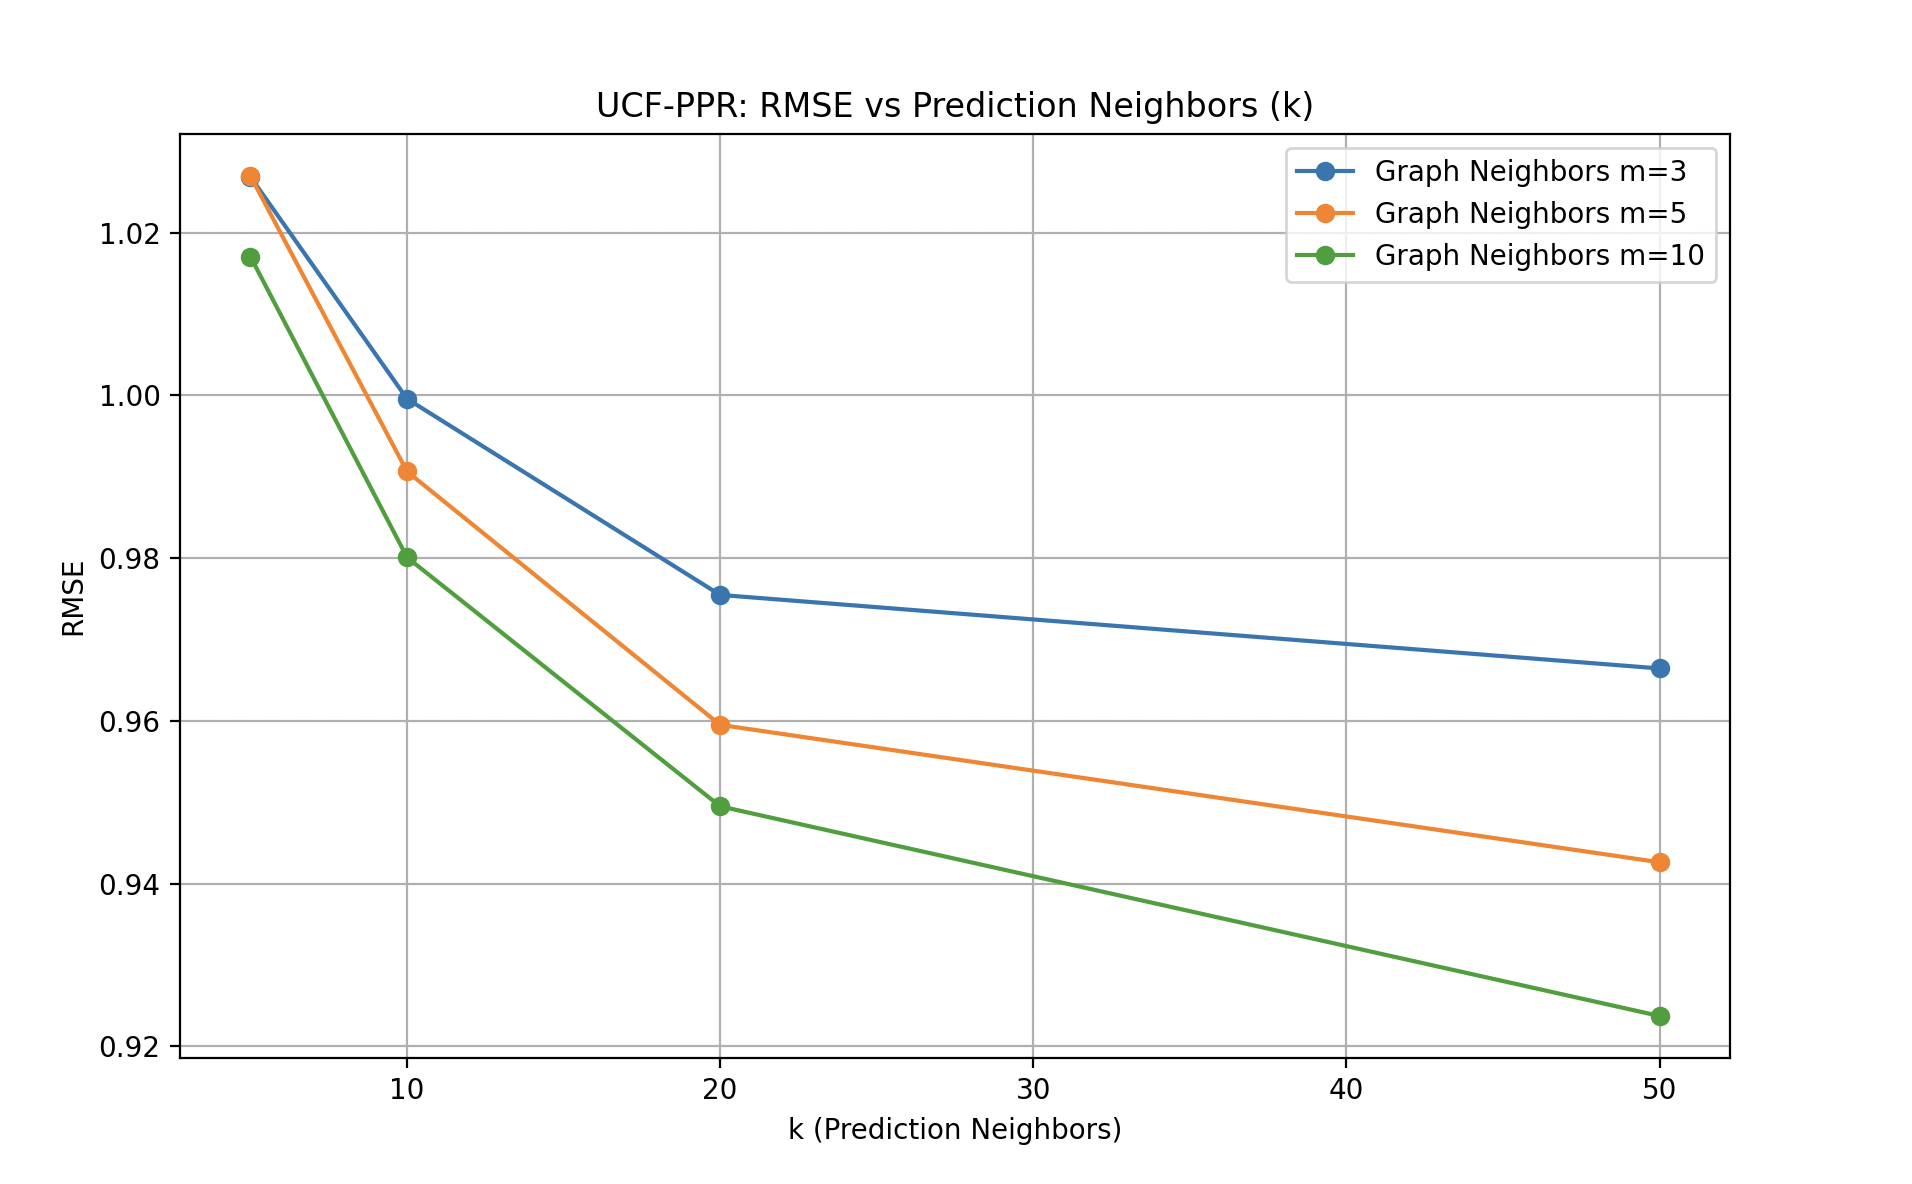

#Ανάλυση Αποτελεσμάτων

Από το γράφημα RMSE ως προς τον αριθμό γειτόνων πρόβλεψης k παρατηρείται ότι η απόδοση του αλγορίθμου βελτιώνεται καθώς αυξάνεται το k μέχρι ένα σημείο, μετά το οποίο σταθεροποιείται ή παρουσιάζει μικρή επιδείνωση. Επιπλέον, η επιλογή της παραμέτρου m επηρεάζει την απόδοση, καθώς για μικρές τιμές του m ο γράφος είναι πιο αραιός και περιορίζει τη διάδοση της πληροφορίας, ενώ για μεγαλύτερες τιμές (m = 5 ή m = 10) ο γράφος γίνεται πιο πυκνός και οδηγεί σε χαμηλότερες τιμές RMSE.

Το χαμηλότερο RMSE επιτυγχάνεται για m = 10 και k = 50. Η τιμή αυτή είναι χαμηλότερη σε σχέση με το καλύτερο RMSE του κλασικού optimized UCF αλγορίθμου που υλοποιήθηκε στη Δεύτερη Άσκηση. Το αποτέλεσμα αυτό υποδηλώνει ότι η χρήση του Personalized PageRank επιτρέπει την αξιοποίηση της δομής του γράφου χρηστών, λαμβάνοντας υπόψη τόσο άμεσες όσο και έμμεσες ομοιότητες μεταξύ χρηστών, γεγονός που οδηγεί σε πιο σταθερές προβλέψεις.

Συμπερασματικά, η ενσωμάτωση του Personalized PageRank στον UCF αλγόριθμο αποτελεί μια φυσική επέκταση του κλασικού collaborative filtering και μπορεί να βελτιώσει ή να σταθεροποιήσει την απόδοση, ιδιαίτερα σε περιπτώσεις όπου οι άμεσες ομοιότητες μεταξύ χρηστών δεν επαρκούν.
